## Step 1 — Setup and Load Data

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path
import json

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path('..') / 'data' / 'processed' / 'master_occupations.csv'
data = pd.read_csv(DATA_PATH, dtype={'OCC_CODE': str})

print(f'Shape: {data.shape}')
print(f'UAIOE present: {"UAIOE" in data.columns}')
print(f'AIOE present:  {"AIOE" in data.columns}')

Shape: (655, 130)
UAIOE present: True
AIOE present:  True


## Step 2 — Results from NB7 A and NB7 B

In [14]:
emp_results = {
    "ols_full_coef": 6.1947,
  "ols_full_r2": 0.0652,
  "ols_full_adj_r2": 0.0638,
  "ols_full_p": 0.0,
  "ols_full_n": 655.0,
  "ols_1922_coef": 4.0208,
  "ols_1922_r2": 0.0382,
  "ols_1922_p": 0.0,
  "ols_2224_coef": 1.9453,
  "ols_2224_r2": 0.0164,
  "ols_2224_p": 0.001,
  "rf_r2_test": -0.0821,
  "rf_rmse": 20.4162,
  "rf_cv_r2_mean": -0.0118,
  "rf_cv_r2_std": 0.0545
}

wage_results = {
      "ols_full_coef": -3.7094,
  "ols_full_r2": 0.12,
  "ols_full_adj_r2": 0.1187,
  "ols_full_p": 0.0,
  "ols_full_n": 655.0,
  "ols_1922_coef": -2.473,
  "ols_1922_r2": 0.0948,
  "ols_1922_p": 0.0,
  "ols_2224_coef": -1.1594,
  "ols_2224_r2": 0.0293,
  "ols_2224_p": 0.0,
  "rf_r2_test": 0.324,
  "rf_rmse": 7.3798,
  "rf_cv_r2_mean": -0.1107,
  "rf_cv_r2_std": 0.1938
}

print('Results loaded. Run next cells to produce comparison table.')

Results loaded. Run next cells to produce comparison table.


## Step 3 — Model Comparison Table

In [15]:
# Build full model comparison table
def sig_stars(p):
    if isinstance(p, str): return ''
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

comparison = pd.DataFrame([
    {'Model': 'OLS',
     'Outcome': 'Employment Change 2019→2024',
     'Predictor': 'UAIOE',
     'Coefficient': round(emp_results['ols_full_coef'], 4),
     'R²': round(emp_results['ols_full_r2'], 4),
     'Adj R²': round(emp_results['ols_full_adj_r2'], 4),
     'p-value': round(emp_results['ols_full_p'], 4),
     'Sig': sig_stars(emp_results['ols_full_p']),
     'N': emp_results['ols_full_n']},
    {'Model': 'OLS',
     'Outcome': 'Employment Change 2019→2022 (Pre-GenAI)',
     'Predictor': 'UAIOE',
     'Coefficient': round(emp_results['ols_1922_coef'], 4),
     'R²': round(emp_results['ols_1922_r2'], 4),
     'Adj R²': 'N/A',
     'p-value': round(emp_results['ols_1922_p'], 4),
     'Sig': sig_stars(emp_results['ols_1922_p']),
     'N': emp_results['ols_full_n']},
    {'Model': 'OLS',
     'Outcome': 'Employment Change 2022→2024 (GenAI Era)',
     'Predictor': 'UAIOE',
     'Coefficient': round(emp_results['ols_2224_coef'], 4),
     'R²': round(emp_results['ols_2224_r2'], 4),
     'Adj R²': 'N/A',
     'p-value': round(emp_results['ols_2224_p'], 4),
     'Sig': sig_stars(emp_results['ols_2224_p']),
     'N': emp_results['ols_full_n']},
    {'Model': 'OLS',
     'Outcome': 'Wage Change 2019→2024',
     'Predictor': 'UAIOE',
     'Coefficient': round(wage_results['ols_full_coef'], 4),
     'R²': round(wage_results['ols_full_r2'], 4),
     'Adj R²': round(wage_results['ols_full_adj_r2'], 4),
     'p-value': round(wage_results['ols_full_p'], 4),
     'Sig': sig_stars(wage_results['ols_full_p']),
     'N': wage_results['ols_full_n']},
    {'Model': 'OLS',
     'Outcome': 'Wage Change 2019→2022 (Pre-GenAI)',
     'Predictor': 'UAIOE',
     'Coefficient': round(wage_results['ols_1922_coef'], 4),
     'R²': round(wage_results['ols_1922_r2'], 4),
     'Adj R²': 'N/A',
     'p-value': round(wage_results['ols_1922_p'], 4),
     'Sig': sig_stars(wage_results['ols_1922_p']),
     'N': wage_results['ols_full_n']},
    {'Model': 'OLS',
     'Outcome': 'Wage Change 2022→2024 (GenAI Era)',
     'Predictor': 'UAIOE',
     'Coefficient': round(wage_results['ols_2224_coef'], 4),
     'R²': round(wage_results['ols_2224_r2'], 4),
     'Adj R²': 'N/A',
     'p-value': round(wage_results['ols_2224_p'], 4),
     'Sig': sig_stars(wage_results['ols_2224_p']),
     'N': wage_results['ols_full_n']},
    {'Model': 'Random Forest',
     'Outcome': 'Employment Change 2019→2024',
     'Predictor': 'O*NET 93 features',
     'Coefficient': 'N/A',
     'R²': round(emp_results['rf_r2_test'], 4),
     'Adj R²': 'N/A',
     'p-value': 'N/A',
     'Sig': 'N/A',
     'N': emp_results['ols_full_n']},
    {'Model': 'Random Forest',
     'Outcome': 'Wage Change 2019→2024',
     'Predictor': 'O*NET 93 features',
     'Coefficient': 'N/A',
     'R²': round(wage_results['rf_r2_test'], 4),
     'Adj R²': 'N/A',
     'p-value': 'N/A',
     'Sig': 'N/A',
     'N': wage_results['ols_full_n']},
])

print('MODEL COMPARISON TABLE')
print('Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant')
print()
print(comparison.to_string(index=False))

comparison.to_csv('../data/processed/model_comparison.csv', index=False)
print('\nSaved: model_comparison.csv')

MODEL COMPARISON TABLE
Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant

        Model                                 Outcome         Predictor Coefficient      R²  Adj R² p-value Sig     N
          OLS             Employment Change 2019→2024             UAIOE      6.1947  0.0652  0.0638     0.0 *** 655.0
          OLS Employment Change 2019→2022 (Pre-GenAI)             UAIOE      4.0208  0.0382     N/A     0.0 *** 655.0
          OLS Employment Change 2022→2024 (GenAI Era)             UAIOE      1.9453  0.0164     N/A   0.001  ** 655.0
          OLS                   Wage Change 2019→2024             UAIOE     -3.7094  0.1200  0.1187     0.0 *** 655.0
          OLS       Wage Change 2019→2022 (Pre-GenAI)             UAIOE      -2.473  0.0948     N/A     0.0 *** 655.0
          OLS       Wage Change 2022→2024 (GenAI Era)             UAIOE     -1.1594  0.0293     N/A     0.0 *** 655.0
Random Forest             Employment Change 2019→2024 O*NET 93 features         N

## Step 4 — UAIOE vs AIOE: Which Predicts Better?

In [16]:
# Run same OLS regressions using AIOE instead of UAIOE
# Compare R² to see what UAIOE adds
results_compare = []

for predictor in ['UAIOE', 'AIOE']:
    for outcome, label in [
        ('emp_change_pct_19_24', 'Employment 2019→2024'),
        ('emp_change_pct_19_22', 'Employment 2019→2022'),
        ('emp_change_pct_22_24', 'Employment 2022→2024'),
        ('wage_change_pct_19_24', 'Wage 2019→2024'),
        ('wage_change_pct_19_22', 'Wage 2019→2022'),
        ('wage_change_pct_22_24', 'Wage 2022→2024'),
    ]:
        df_sub = data.dropna(subset=[predictor, outcome])
        X = sm.add_constant(df_sub[predictor])
        y = df_sub[outcome]
        model = sm.OLS(y, X).fit()
        results_compare.append({
                    'Predictor': predictor,
                    'Outcome': label,
                    'R²': round(model.rsquared, 4),
                    'Coefficient': round(model.params.iloc[1], 4),
                    'p-value': round(model.pvalues.iloc[1], 4)
                })

compare_df = pd.DataFrame(results_compare)

# Pivot to side-by-side comparison
compare_pivot = compare_df.pivot_table(
    index='Outcome',
    columns='Predictor',
    values='R²'
).round(4)

compare_pivot['UAIOE_better'] = compare_pivot['UAIOE'] > compare_pivot['AIOE']
compare_pivot['R²_difference'] = (compare_pivot['UAIOE'] - compare_pivot['AIOE']).round(4)

print('UAIOE vs AIOE — R² Comparison')
print('(Positive difference = UAIOE predicts better)')
print()
print(compare_pivot.to_string())

n_better = compare_pivot['UAIOE_better'].sum()
print(f'\nUAIOE outperforms AIOE in {n_better}/6 outcomes')

compare_pivot.to_csv('../data/processed/uaioe_vs_aioe_comparison.csv')
print('Saved: uaioe_vs_aioe_comparison.csv')

UAIOE vs AIOE — R² Comparison
(Positive difference = UAIOE predicts better)

Predictor               AIOE   UAIOE  UAIOE_better  R²_difference
Outcome                                                          
Employment 2019→2022  0.0259  0.0382          True         0.0123
Employment 2019→2024  0.0368  0.0652          True         0.0284
Employment 2022→2024  0.0058  0.0164          True         0.0106
Wage 2019→2022        0.0980  0.0948         False        -0.0032
Wage 2019→2024        0.1090  0.1200          True         0.0110
Wage 2022→2024        0.0215  0.0293          True         0.0078

UAIOE outperforms AIOE in 5/6 outcomes
Saved: uaioe_vs_aioe_comparison.csv


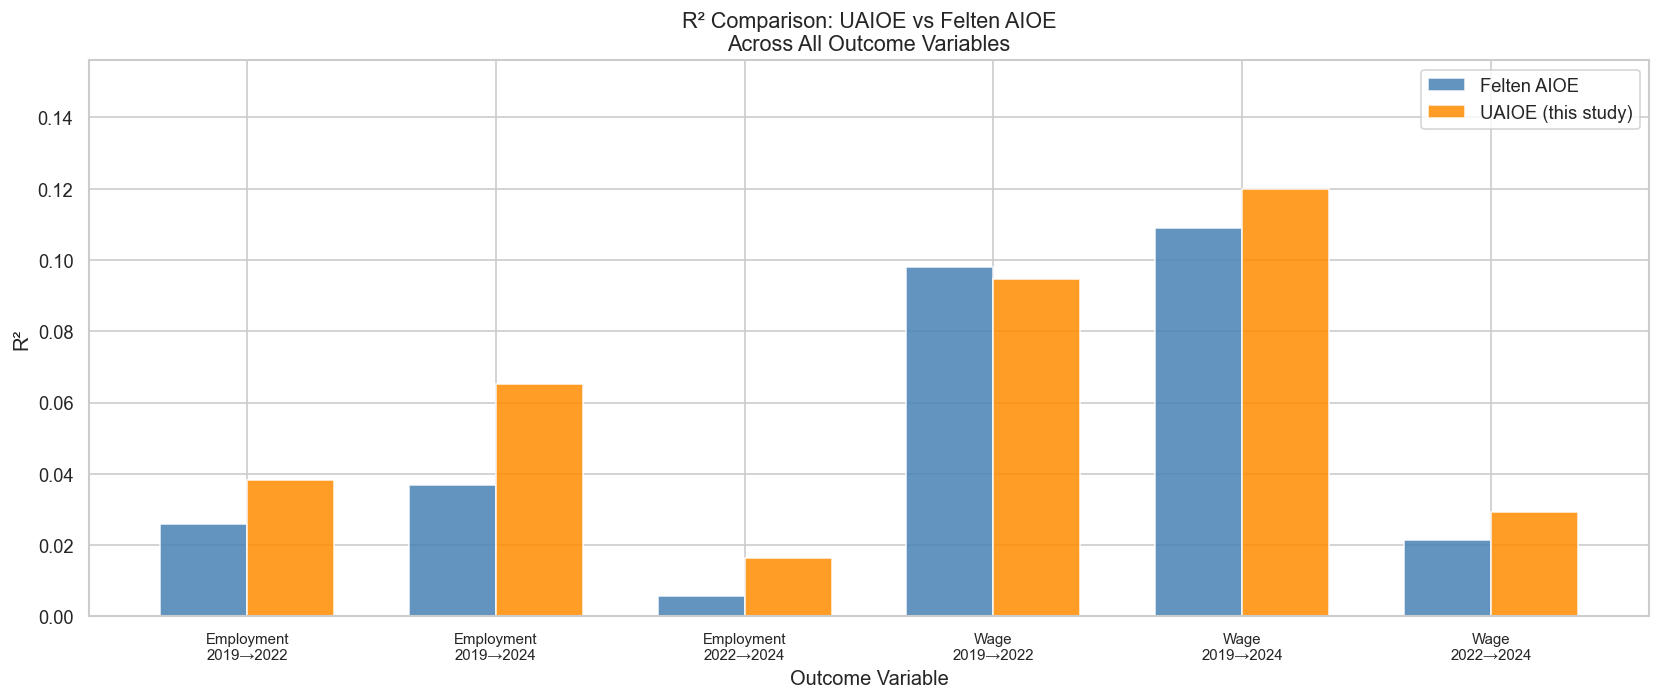

In [17]:
# Visualize UAIOE vs AIOE R² comparison
outcomes = compare_pivot.index.tolist()
x = np.arange(len(outcomes))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, compare_pivot['AIOE'],
               width, label='Felten AIOE',
               color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, compare_pivot['UAIOE'],
               width, label='UAIOE (this study)',
               color='darkorange', alpha=0.85)

ax.set_title('R² Comparison: UAIOE vs Felten AIOE\nAcross All Outcome Variables',
             fontsize=13)
ax.set_ylabel('R²')
ax.set_xlabel('Outcome Variable')
ax.set_xticks(x)
ax.set_xticklabels([o.replace(' ', '\n') for o in outcomes],
                   fontsize=9)
ax.legend()
ax.set_ylim(0, max(compare_pivot[['AIOE', 'UAIOE']].max()) * 1.3)
plt.tight_layout()
plt.show()

## Step 5 — Two-Interval Visualization

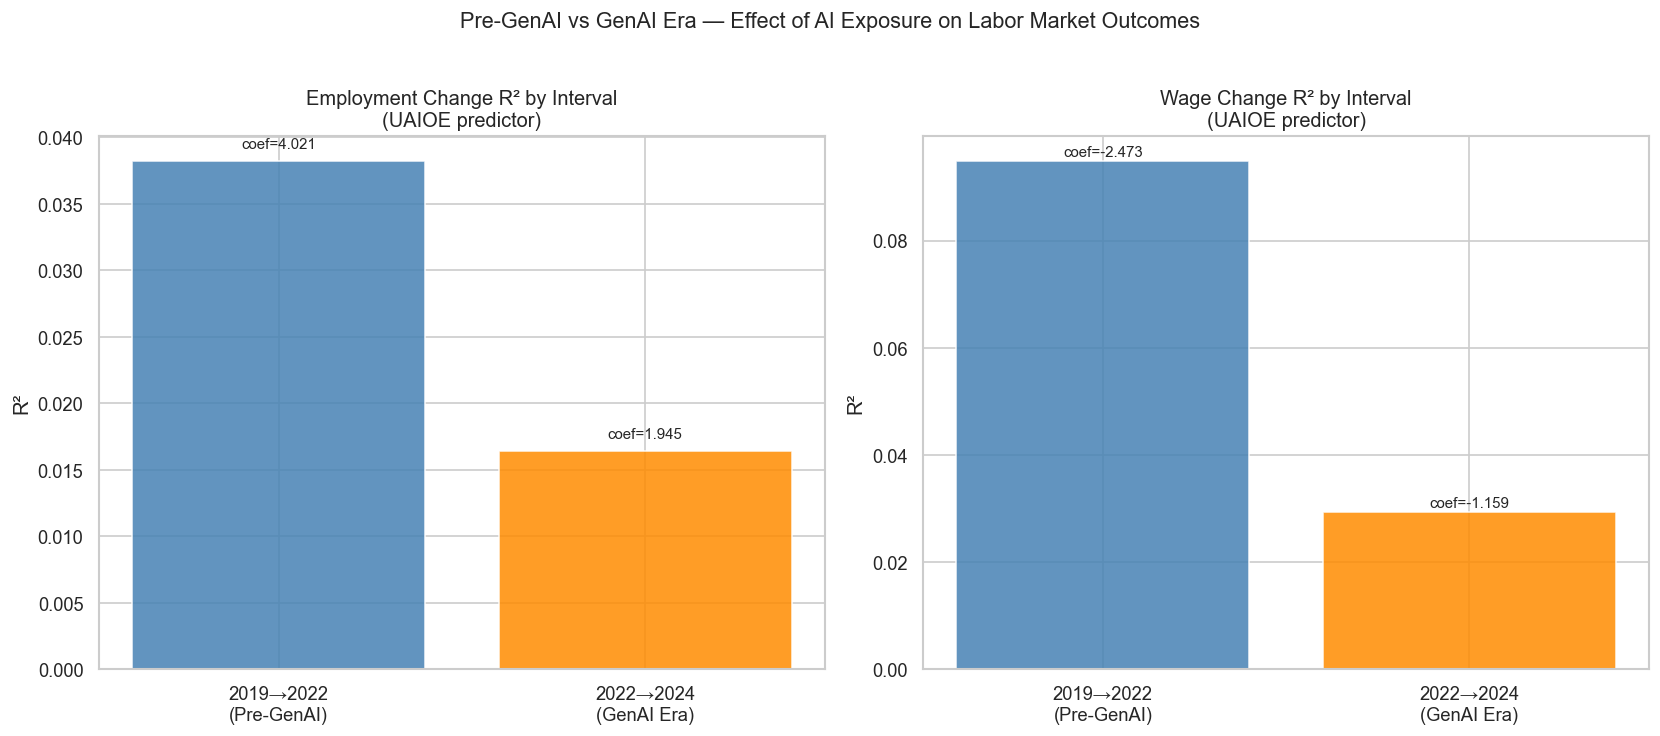

In [18]:
# R² by interval — employment and wage side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Employment intervals
emp_r2 = [
    emp_results['ols_1922_r2'],
    emp_results['ols_2224_r2']
]
emp_coef = [
    emp_results['ols_1922_coef'],
    emp_results['ols_2224_coef']
]
labels = ['2019→2022\n(Pre-GenAI)', '2022→2024\n(GenAI Era)']
colors = ['steelblue', 'darkorange']

bars = axes[0].bar(labels, emp_r2, color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('Employment Change R² by Interval\n(UAIOE predictor)', fontsize=12)
axes[0].set_ylabel('R²')
for bar, coef in zip(bars, emp_coef):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'coef={coef:.3f}', ha='center', fontsize=9)

# Wage intervals
wage_r2 = [
    wage_results['ols_1922_r2'],
    wage_results['ols_2224_r2']
]
wage_coef = [
    wage_results['ols_1922_coef'],
    wage_results['ols_2224_coef']
]

bars2 = axes[1].bar(labels, wage_r2, color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Wage Change R² by Interval\n(UAIOE predictor)', fontsize=12)
axes[1].set_ylabel('R²')
for bar, coef in zip(bars2, wage_coef):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'coef={coef:.3f}', ha='center', fontsize=9)

plt.suptitle('Pre-GenAI vs GenAI Era — Effect of AI Exposure on Labor Market Outcomes',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

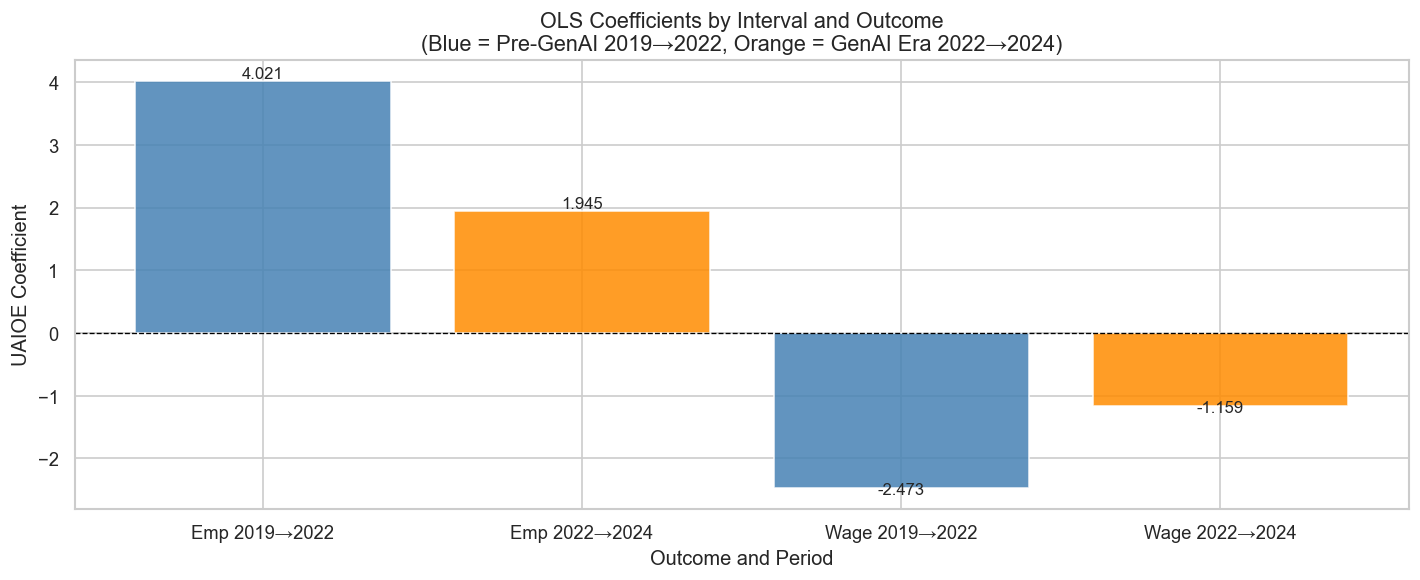

In [19]:
# Coefficient comparison across intervals — employment and wage
fig, ax = plt.subplots(figsize=(12, 5))

interval_labels = ['Emp 2019→2022', 'Emp 2022→2024',
                   'Wage 2019→2022', 'Wage 2022→2024']
coefficients = [
    emp_results['ols_1922_coef'],
    emp_results['ols_2224_coef'],
    wage_results['ols_1922_coef'],
    wage_results['ols_2224_coef']
]
bar_colors = ['steelblue', 'darkorange', 'steelblue', 'darkorange']

bars = ax.bar(interval_labels, coefficients,
              color=bar_colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('OLS Coefficients by Interval and Outcome\n'
             '(Blue = Pre-GenAI 2019→2022, Orange = GenAI Era 2022→2024)',
             fontsize=13)
ax.set_ylabel('UAIOE Coefficient')
ax.set_xlabel('Outcome and Period')

for bar, coef in zip(bars, coefficients):
    offset = 0.05 if coef >= 0 else -0.1
    ax.text(bar.get_x() + bar.get_width()/2,
            coef + offset,
            f'{coef:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Step 6 — Key Findings Summary

In [20]:
print('=' * 65)
print('KEY FINDINGS')
print('=' * 65)

print(f'\n── Employment Change 2019→2024 ─────────────────────────')
print(f'  OLS R²:            {emp_results["ols_full_r2"]:.4f}')
print(f'  OLS Coefficient:   {emp_results["ols_full_coef"]:.4f}')
print(f'  p-value:           {emp_results["ols_full_p"]:.4f}',
      '***' if emp_results['ols_full_p'] < 0.001 else
      ('**' if emp_results['ols_full_p'] < 0.01 else
       ('*' if emp_results['ols_full_p'] < 0.05 else 'ns')))
print(f'  RF R² (test):      {emp_results["rf_r2_test"]:.4f}')
print(f'  RF CV R²:          {emp_results["rf_cv_r2_mean"]:.4f} ± {emp_results["rf_cv_r2_std"]:.4f}')

print(f'\n── Wage Change 2019→2024 ───────────────────────────────')
print(f'  OLS R²:            {wage_results["ols_full_r2"]:.4f}')
print(f'  OLS Coefficient:   {wage_results["ols_full_coef"]:.4f}')
print(f'  p-value:           {wage_results["ols_full_p"]:.4f}',
      '***' if wage_results['ols_full_p'] < 0.001 else
      ('**' if wage_results['ols_full_p'] < 0.01 else
       ('*' if wage_results['ols_full_p'] < 0.05 else 'ns')))
print(f'  RF R² (test):      {wage_results["rf_r2_test"]:.4f}')
print(f'  RF CV R²:          {wage_results["rf_cv_r2_mean"]:.4f} ± {wage_results["rf_cv_r2_std"]:.4f}')

print(f'\n── Two-Interval Comparison ─────────────────────────────')
print(f'  Employment Pre-GenAI R²:   {emp_results["ols_1922_r2"]:.4f}')
print(f'  Employment GenAI Era R²:   {emp_results["ols_2224_r2"]:.4f}')
stronger_emp = 'GenAI Era' if emp_results['ols_2224_r2'] > emp_results['ols_1922_r2'] else 'Pre-GenAI'
print(f'  Stronger period:           {stronger_emp}')
print()
print(f'  Wage Pre-GenAI R²:         {wage_results["ols_1922_r2"]:.4f}')
print(f'  Wage GenAI Era R²:         {wage_results["ols_2224_r2"]:.4f}')
stronger_wage = 'GenAI Era' if wage_results['ols_2224_r2'] > wage_results['ols_1922_r2'] else 'Pre-GenAI'
print(f'  Stronger period:           {stronger_wage}')

print(f'\n── UAIOE vs AIOE ───────────────────────────────────────')
n_better = compare_pivot['UAIOE_better'].sum()
print(f'  UAIOE outperforms AIOE in: {n_better}/6 outcomes')
print(f'  Mean R² difference:        {compare_pivot["R²_difference"].mean():.4f}')

print(f'\n── Outputs Saved ───────────────────────────────────────')
print(f'  data/processed/model_comparison.csv')
print(f'  data/processed/uaioe_vs_aioe_comparison.csv')

KEY FINDINGS

── Employment Change 2019→2024 ─────────────────────────
  OLS R²:            0.0652
  OLS Coefficient:   6.1947
  p-value:           0.0000 ***
  RF R² (test):      -0.0821
  RF CV R²:          -0.0118 ± 0.0545

── Wage Change 2019→2024 ───────────────────────────────
  OLS R²:            0.1200
  OLS Coefficient:   -3.7094
  p-value:           0.0000 ***
  RF R² (test):      0.3240
  RF CV R²:          -0.1107 ± 0.1938

── Two-Interval Comparison ─────────────────────────────
  Employment Pre-GenAI R²:   0.0382
  Employment GenAI Era R²:   0.0164
  Stronger period:           Pre-GenAI

  Wage Pre-GenAI R²:         0.0948
  Wage GenAI Era R²:         0.0293
  Stronger period:           Pre-GenAI

── UAIOE vs AIOE ───────────────────────────────────────
  UAIOE outperforms AIOE in: 5/6 outcomes
  Mean R² difference:        0.0112

── Outputs Saved ───────────────────────────────────────
  data/processed/model_comparison.csv
  data/processed/uaioe_vs_aioe_comparison.csv
